<a href="https://colab.research.google.com/github/Zhr-Srj/TripSimAcin-AMR/blob/main/Code/KEGG_validation2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In this notebook I want to compare our model with traditional machine learning models, on KEGG-selected genes (96 + **303 SHAP-selected drug features**), 5 times and report the results in the form of average over results of these 5 times.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Required packages

In [ ]:
pip install xgboost

In [ ]:
import sys
import gc

import csv
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import random
from random import sample, shuffle

from sklearn.utils import shuffle as sk_shuffle

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, confusion_matrix, accuracy_score, f1_score
from sklearn.model_selection import KFold

from tensorflow.keras.layers import Input, Dense, Dropout, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import AUC
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import LayerNormalization
from tensorflow.keras.callbacks import  History

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import xgboost

# Data prepation

## Loading train-test dataset

In [ ]:
with open(r'/content/drive/MyDrive/Dataset19.txt') as f:
    data = []
    for line in f.readlines():
        row = []
        for elem in line.split(sep=','):
            row.append(int(elem.strip()))
        data.append(row)
print(len(data))
print(len(data[0]))

7207
8886


In [ ]:
#Reading phenotypes file
with open(r'/content/drive/MyDrive/drugLabel19.txt') as fy:
    labels = []
    drugs = [] #stores drug name in each row
    row = 0 # row number of each label (is needed because data is reordered while spliting)
    reader = csv.reader(fy)
    for i in reader:
        labels.append([row, int(i[1])])
        drugs.append(i[0])
        row += 1

print(len(labels))
print(len(drugs))
print(labels[:5])

7207
7207
[[0, 1], [1, 1], [2, 0], [3, 0], [4, 1]]


In [ ]:
labels = np.asarray(labels)

# Loading KEGG-based features

In [ ]:
kegg_selection = []
with open("/content/drive/MyDrive/Master_new_Sep/Revise/KEGG_Columns.txt") as f:
  for i in f.readlines():
    kegg_selection.append(int(i.strip()))

print(len(kegg_selection))

96


# Loading SHAP-based features

In [ ]:
dropped = []
with open("/content/drive/MyDrive/To_drop_features.csv") as f:
  f.readline()
  dropped  = [int(i) for i in f.readline().strip().split(',')]

for i in range(8886):
  if i not in dropped and i >= 8005:
    kegg_selection.append(i)

print(len(kegg_selection))

399


In [ ]:
import numpy as np

data_np = np.asarray(data)

all_selected_indices = sorted(kegg_selection)

data_kegg = data_np[:, all_selected_indices]

print(len(data_kegg))
print(len(data_kegg[0]))

7207
399


In [ ]:
del data_np
data = data_kegg
del data_kegg

In [ ]:
data = data.tolist()

### Removing duplicates

In [ ]:
duplicate = any(data.count(element) > 1 for element in data)
duplicate

True

In [ ]:
l = [data.count(element) > 1 for element in data]
l[:10]

[True, True, True, True, True, True, True, True, True, True]

In [ ]:
len([i for i in l if i==True])

7051

In [ ]:
reps = {}
for element in data:
  if np.asarray(element).tobytes() not in reps.keys():
    num = data.count(element)
    if num > 1:
      reps[np.asarray(element).tobytes()] = num

In [ ]:
len(reps.keys())

251

In [ ]:
reps.values()

dict_values([8, 33, 284, 284, 301, 198, 286, 59, 41, 8, 53, 74, 10, 9, 3, 194, 17, 270, 37, 300, 182, 191, 76, 278, 198, 58, 15, 28, 75, 193, 194, 35, 77, 190, 115, 8, 2, 236, 62, 10, 71, 48, 15, 12, 17, 45, 58, 74, 26, 278, 46, 183, 55, 55, 34, 4, 57, 7, 20, 4, 5, 16, 4, 35, 8, 8, 17, 5, 10, 10, 8, 44, 4, 2, 10, 12, 3, 2, 5, 9, 7, 4, 18, 7, 5, 8, 8, 56, 7, 6, 5, 10, 10, 9, 28, 65, 15, 8, 18, 17, 8, 2, 34, 8, 8, 11, 6, 5, 11, 7, 6, 6, 5, 8, 2, 5, 5, 15, 8, 6, 3, 6, 2, 15, 8, 3, 5, 5, 2, 4, 5, 7, 18, 14, 5, 3, 8, 43, 2, 4, 5, 2, 2, 6, 2, 3, 7, 3, 7, 3, 8, 2, 4, 8, 4, 9, 2, 2, 2, 3, 5, 3, 4, 8, 4, 2, 3, 5, 2, 2, 3, 3, 2, 2, 8, 4, 4, 3, 2, 2, 3, 7, 3, 5, 4, 2, 8, 4, 5, 4, 3, 2, 2, 5, 3, 6, 4, 10, 4, 3, 5, 2, 2, 2, 7, 7, 2, 2, 4, 3, 2, 2, 4, 2, 2, 5, 6, 7, 3, 3, 3, 3, 2, 2, 2, 2, 2, 4, 4, 2, 2, 2, 2, 3, 5, 2, 2, 2, 3, 2, 3, 2, 2, 3, 2, 2, 4, 3, 3, 2, 3])

In [ ]:
sum(reps.values())

7051

In [ ]:
print(len(data))
print( sum(reps.values()) )
print(len(reps.keys()))
print(len(data) - sum(reps.values()) + len(reps.keys()))

7207
7051
251
407


In [ ]:
added = []
data_unique = []
drugs_unique = []

labels_unique = []
for idx, element in enumerate(data):
  if np.asarray(element).tobytes() not in added:
    added.append(np.asarray(element).tobytes())
    data_unique.append(element)
    labels_unique.append(labels[idx])
    drugs_unique.append(drugs[idx])

len(data_unique)

407

In [ ]:
orig_data = data_unique
orig_labels = labels_unique

In [ ]:
del data_unique
len(orig_data)

407

In [ ]:
del labels_unique
len(orig_labels)

407

In [ ]:
duplicate = any(orig_data.count(element) > 1 for element in orig_data)
duplicate

False

### A survey on data

In [ ]:
unq_drugs = set(drugs)
len(unq_drugs)

12

In [ ]:
per_drug_dic = {}
for i in orig_labels:
  drug = drugs[i[0]]
  label = i[1]
  if drug not in per_drug_dic.keys():
    per_drug_dic[drug] = [0, 0]  # num of resistant, num of susceptible
  if label == 0:
    per_drug_dic[drug][1] += 1
  else:
    per_drug_dic[drug][0] += 1

per_drug_dic

{'gentamicin': [34, 6],
 'levofloxacin': [25, 13],
 'ceftazidime': [27, 13],
 'imipenem': [16, 26],
 'tetracycline': [24, 12],
 'amikacin': [21, 20],
 'cefotaxime': [28, 3],
 'ciprofloxacin': [31, 10],
 'ceftriaxone': [30, 2],
 'meropenem': [17, 15],
 'doripenem': [11, 11],
 'moxifloxacin': [6, 6]}

## Train-Test split

In [ ]:
def balanced_train_test_split(data, labels, drugs, n, rs):
  """
  Performs a train_test_split, setting n susceptibles and n resistant strains aside for each drug
  returns x_train, x_test, y_train, y_test
  """

  data, labels = sk_shuffle(data, labels, random_state=rs)

  x_train = []
  x_test = []
  y_train = []
  y_test = []

  idx = {} # A dic containig indices of susceptible and resistant strain
            # for each drug

  unq_drugs = list(set(drugs))

  for drug_name in unq_drugs:

    drug_indx_S = []
    drug_indx_R = []

    for i in range(len(labels)):
      j, l = labels[i][0], labels[i][1]
      if drugs[j] == drug_name:
        if l == 0:
          drug_indx_S.append(i)
        else:
          drug_indx_R.append(i)

    idx[(drug_name, 'S')] = drug_indx_S
    idx[(drug_name, 'R')] = drug_indx_R

  len_xtrain = 0
  len_xtest = 0

  for drug in unq_drugs:

    num = min(len(idx[(drug, 'S')]), len(idx[(drug, 'R')]))
    if num < 2*n:
      num = int(num/2)
    else:
      num = n

    s_set = idx[(drug, 'S')]
    for i in range(len(s_set)-num):
      x_train.append(data[s_set[i]])
      y_train.append(labels[s_set[i]])
    for i in range(1, num+1):
      x_test.append(data[s_set[-i]])
      y_test.append(labels[s_set[-i]])

    r_set = idx[(drug, 'R')]
    for i in range(len(r_set)-num):
      x_train.append(data[r_set[i]])
      y_train.append(labels[r_set[i]])
    for i in range(1, num+1):
      x_test.append(data[r_set[-i]])
      y_test.append(labels[r_set[-i]])

    print(len(s_set), len(r_set))

    # For confirming it's working properly
    print("for drug ", drug, "# of train samples: ", len(x_train)-len_xtrain )
    len_xtrain = len(x_train)
    print("for drug ", drug, "# of test samples: ", len(x_test)-len_xtest )
    len_xtest = len(x_test)

  return x_train, x_test, y_train, y_test

In [ ]:
def make_balanced_triplets(samples, labels, drugs, num):
  """For each drug in drugs samples...
  makes:
  - n triplets which are both Susceptible to drug (S, S)
  - n triplets which are (R, R)
  - n triplets which are (S, R)
  - n triplets which are (R, S)
  """
  bac_shape = 96

  idx = {} # A dic containig indices of susceptible and resistant strain
            # for each drug

  triplet = [] # Made from samples which are not part of external_test_sets
  triLabels = [] # Labels corresponding to triplets

  unq_drugs = list(set(drugs))

  for drug_name in unq_drugs:

    drug_indx_S = []
    drug_indx_R = []
    for i in range(len(labels)):
      j, l = labels[i][0], labels[i][1]
      if drugs[j] == drug_name:
        if l == 0:
          drug_indx_S.append(i)
        else:
          drug_indx_R.append(i)
    idx[(drug_name, 'S')] = drug_indx_S
    idx[(drug_name, 'R')] = drug_indx_R

  for drug in unq_drugs:

    s_len = len(idx[(drug, 'S')])
    r_len = len(idx[(drug, 'R')])
    n = min(num, int(s_len*(s_len-1)/2), int(r_len*(r_len-1)/2))

    ss = [(i, j) for i in idx[(drug, 'S')] for j in idx[(drug, 'S')] if j>i]
    # ss_sampled = sample(ss, n)

    rr = [(i, j) for i in idx[(drug, 'R')] for j in idx[(drug, 'R')] if j>i]
    # rr_sampled = sample(rr, n)

    rs_temp = [(i, j) for i in idx[(drug, 'R')] for j in idx[(drug, 'S')]]
    # neg_samples = sample(rs, 2*n)
    rs = rs_temp[:n]
    sr = [(t[1], t[0]) for t in rs_temp[n:]]

    for k in range(len(ss)):
      # Making (S, S, d) triplets
      triplet.append( samples[ss[k][0]][:bac_shape] + samples[ss[k][1]][:bac_shape] +
                        samples[ss[k][0]][bac_shape:] )
      triLabels.append([1, 0]) # 1: both phenos the same. First: 0, sencond? --> 0

    for k in range(len(rr)):
      # Making (R, R, d) triplets
      triplet.append( samples[rr[k][0]][:bac_shape] + samples[rr[k][1]][:bac_shape] +
                        samples[rr[k][0]][bac_shape:] )
      triLabels.append([1, 1]) # 1: both phenos the same. First: 1, sencond? --> 1

    for k in range(len(rs)):
      # Making (R, S, d) triplets
      triplet.append( samples[rs[k][0]][:bac_shape] + samples[rs[k][1]][:bac_shape] +
                         samples[rs[k][0]][bac_shape:])
      triLabels.append([0, 1]) # 0: phenos different. First: 1, sencond? --> 0

    for k in range(len(sr)):
      # Making (S, R, d) triplets
      triplet.append( samples[sr[k][0]][:bac_shape] + samples[sr[k][1]][:bac_shape] +
                         samples[sr[k][0]][bac_shape:])
      triLabels.append([0, 0]) # 0: phenos different. First: 0, sencond? --> 1

  return np.array(triplet), np.array(triLabels)

In [ ]:
len(orig_data)

407

In [ ]:
# Splitting data
train_set, test_set, train_labels, test_labels = balanced_train_test_split(orig_data, orig_labels, drugs, 5, 42)

3 28
for drug  cefotaxime # of train samples:  29
for drug  cefotaxime # of test samples:  2
10 31
for drug  ciprofloxacin # of train samples:  31
for drug  ciprofloxacin # of test samples:  10
26 16
for drug  imipenem # of train samples:  32
for drug  imipenem # of test samples:  10
13 27
for drug  ceftazidime # of train samples:  30
for drug  ceftazidime # of test samples:  10
11 11
for drug  doripenem # of train samples:  12
for drug  doripenem # of test samples:  10
2 30
for drug  ceftriaxone # of train samples:  30
for drug  ceftriaxone # of test samples:  2
6 6
for drug  moxifloxacin # of train samples:  6
for drug  moxifloxacin # of test samples:  6
15 17
for drug  meropenem # of train samples:  22
for drug  meropenem # of test samples:  10
13 25
for drug  levofloxacin # of train samples:  28
for drug  levofloxacin # of test samples:  10
12 24
for drug  tetracycline # of train samples:  26
for drug  tetracycline # of test samples:  10
20 21
for drug  amikacin # of train samples:

In [ ]:
triplet, pairedLabels =  make_balanced_triplets(train_set, train_labels, drugs, 400)

In [ ]:
print(len(triplet))
print(len(triplet[0]))
print(len(pairedLabels))
print(pairedLabels[0])

4278
495
4278
[1 0]


In [ ]:
train_labels = np.asarray(train_labels)
pairedLabels = np.asarray(pairedLabels)

# Evaluation functions

In [ ]:
def evaluation(true_labels, pred_labels):

  Dis_pred = []
  for i in pred_labels:
    if i < 0.5:
      Dis_pred.append(0)
    else:
      Dis_pred.append(1)

  acc = accuracy_score(true_labels, Dis_pred)
  auc = roc_auc_score(true_labels, Dis_pred)
  print('Accuracy: ', acc)
  print('ROC-AUC: ', auc)

  TN, FP, FN, TP = confusion_matrix(true_labels, Dis_pred, labels=[0, 1]).ravel()
  sen = TP/(TP+FN)
  spc = TN/(TN+FP)
  print("Sensitivity: ", sen)
  print('Specificity: ', spc)

  conf_matrix = confusion_matrix(true_labels, Dis_pred, labels=[0, 1])
  plt.figure(figsize=(4, 4))
  sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
              xticklabels=['Predicted Negative', 'Predicted Positive'],
              yticklabels=['True Negative', 'True Positive'])
  plt.xlabel('Predicted')
  plt.ylabel('Actual')
  plt.title('Confusion Matrix')
  plt.show()

  return acc, auc, sen, spc

# Deep model architecture

In [ ]:
def create_siamese_model(input_shape1, input_shape2, input_shape3):

    right_input = Input(shape=input_shape2)
    left_input = Input(shape=input_shape1)
    third_input = Input(shape=input_shape3)

    shared_layer1 = Dense(64, activation='leaky_relu')
    shared_layer2 = Dense(32, activation='leaky_relu')
    shared_layer3 = Dense(16, activation='leaky_relu')
    shared_bn = BatchNormalization() # shared batch normalization layer
    drug_bn = BatchNormalization() # drug batch normalization layer

    encoded_l = shared_layer1(left_input)
    encoded_l = Dropout(0.2)(encoded_l)
    encoded_l = shared_layer2(encoded_l)
    encoded_l = Dropout(0.2)(encoded_l)
    encoded_l = shared_layer3(encoded_l)
    encoded_l = Dropout(0.2)(encoded_l)
    encoded_l = shared_bn(encoded_l)

    encoded_r = shared_layer1(right_input)
    encoded_r = Dropout(0.2)(encoded_r)
    encoded_r = shared_layer2(encoded_r)
    encoded_r = Dropout(0.2)(encoded_r)
    encoded_r = shared_layer3(encoded_r)
    encoded_r = Dropout(0.2)(encoded_r)
    encoded_r = shared_bn(encoded_r)

    encoded_c = Dense(256, activation='leaky_relu')(third_input)
    encoded_c = Dropout(0.2)(encoded_c)
    encoded_c = Dense(128, activation='leaky_relu')(encoded_c)
    encoded_c = Dropout(0.2)(encoded_c)
    encoded_c = Dense(16, activation='leaky_relu')(encoded_c)
    encoded_c = Dropout(0.2)(encoded_c)
    encoded_c = drug_bn(encoded_c)

    concatenated = Concatenate()([encoded_l, encoded_r, encoded_c])

    dense1 = Dense(32, activation='leaky_relu')(concatenated)
    dense1 = Dropout(0.2)(dense1)
    dense2 = Dense(16, activation='leaky_relu')(dense1)
    dense2 = Dropout(0.2)(dense2)
    prediction = Dense(1, activation='sigmoid')(dense2)

    siamese_net = Model(inputs=[left_input, right_input, third_input], outputs=prediction)

    optimizer = Adam(learning_rate=0.001)
    siamese_net.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=["accuracy", AUC(name='auc-roc')])

    return siamese_net

# Evaluations

## Functions
Performance on queries

So each label is a list of size 2

In [ ]:
def ExternalTest(x0_test,x1_test,x0_train,x1_train):
  """
  Takes as input paired data and
  makes each test sample pair with train samples of the same drug (triplet --> b1, b2, d).
  x0_test: test samples with phenotype 0
  x1_test: test samples with phenotype 1
  x0_train: train samples with phenotype 0
  x1_train: train samples with phenotype 1
  """
  dataset_test1=[] # concat train
  label_test1=[]
  Indexsample=[]

  for i in range(len(x0_test)):
    for j in range(len(x0_train)):
      if (x0_test[i][96:] == x0_train[j][96:]).all():
        dataset_test1.append(np.concatenate((x0_test[i][0:96],x0_train[j]), axis=None))
        label_test1.append(1)
        Indexsample.append(str(i)+",0,0")   #index in test, x0_test pheno, x0_train pheno

  for i in range(len(x0_test)):
    for j in range(len(x1_train)):
      if (x0_test[i][96:] == x1_train[j][96:]).all():
        dataset_test1.append(np.concatenate((x0_test[i][0:96],x1_train[j]), axis=None))
        label_test1.append(0)
        Indexsample.append(str(i)+",0,1")   #index in test, x0_test pheno, x1_train pheno


  for i in range(len(x1_test)):
    for j in range(len(x0_train)):
      if (x1_test[i][96:] == x0_train[j][96:]).all():
        dataset_test1.append(np.concatenate((x1_test[i][0:96],x0_train[j]), axis=None))
        label_test1.append(0)
        Indexsample.append(str(i)+",1,0")  #index in test,x1_test,x0_train


  for i in range(len(x1_test)):
    for j in range(len(x1_train)):
      if (x1_test[i][96:] == x1_train[j][96:]).all():
        dataset_test1.append(np.concatenate((x1_test[i][0:96],x1_train[j]), axis=None))
        label_test1.append(1)
        Indexsample.append(str(i)+",1,1")  #index in test,x1_test,x1_train

  return (np.asarray(dataset_test1), np.asarray(label_test1), Indexsample)

In [ ]:
def DefineTest2(x0_test, x1_test, Indexsample, y_pred):
  Pred=[]
  Label=[]

  # START of x0_test
  for i in range(len(x0_test)):
    cnt0Pred=0
    cnt1Pred=0
    cnt1=0
    cnt0=0

    for j in range(len(Indexsample)):
      triplet=Indexsample[j].split(",")   #pair[0] is index from test, pair[1] identifies which test x0_test or s1_test, pair[2] identifies which x0
      if int(triplet[0])==i: #index test
        if int(triplet[1])==0: #type test

          if int(triplet[2])==1: #type train
              cnt1Pred=cnt1Pred+y_pred[j]
              cnt1=cnt1+1

          if int(triplet[2])==0: #type train
              cnt0Pred=cnt0Pred+y_pred[j]
              cnt0=cnt0+1

    pos=(1-(cnt0Pred/cnt0))+(cnt1Pred/cnt1)
    neg=(cnt0Pred/cnt0)+(1-(cnt1Pred/cnt1))
    Pred.append(pos/(pos+neg))
    Label.append(0)

  # END of x0_test
  ######################################################
  # START of x1_test
  for i in range(len(x1_test)):
    cnt0Pred=0
    cnt1Pred=0
    cnt1=0
    cnt0=0
    for j in range(len(Indexsample)):
      triplet=Indexsample[j].split(",")   #pair[0] is index from test, pair[1] identifies which test x0_test or s1_test, pair[2] identifies which x0
      if int(triplet[0])==i: #index test
        if int(triplet[1])==1: #type test

          if int(triplet[2])==0: #type train
              cnt0Pred=cnt0Pred+y_pred[j]
              cnt0=cnt0+1

          if int(triplet[2])==1: #type train
              cnt1Pred=cnt1Pred+y_pred[j]
              cnt1=cnt1+1

    pos=(1-(cnt0Pred/cnt0))+(cnt1Pred/cnt1)
    neg=(cnt0Pred/cnt0)+(1-(cnt1Pred/cnt1))
    Pred.append(pos/(pos+neg))
    Label.append(1)

  return(Pred,Label)

In [ ]:
def RS_splitter(data, labels):
  """
  Takes as input a dataset and corresponding labels (in terms of list of 0s and 1s)
  returns data0, data1
  which are set of susceptible and resistant strains in data, respectively
  """
  data0 = [] # list of susceptible strains' features
  data1 = [] # list of resistant strains' features

  for i, l in enumerate(labels):
    if l == 0:
      data0.append(data[i])
    else:
      data1.append(data[i])

  return data0, data1

In [ ]:
rf_acc = []
rf_auc = []
rf_sen = []
rf_spc = []

svm_acc = []
svm_auc = []
svm_sen = []
svm_spc = []

xgb_acc = []
xgb_auc = []
xgb_sen = []
xgb_spc = []

nn_acc = []
nn_auc = []
nn_sen = []
nn_spc = []

sim_acc = []
sim_auc = []
sim_sen = []
sim_spc = []

# Round 1
random state 42

### Training

#### Random Forest (RF)

In [ ]:
model = RandomForestClassifier(n_estimators=100).fit(train_set, train_labels[:, 1])
predict_RF = model.predict(test_set)

#### SVM

In [ ]:
model = SVC(kernel='poly').fit(train_set, train_labels[:, 1])
predict_SVM = model.predict(test_set)

#### XGBoost

In [ ]:
model = xgboost.XGBClassifier().fit(train_set, train_labels[:, 1])
predict_XGB = model.predict(test_set)

#### Triplet NN

In [ ]:
input_shape1 = (96,)
input_shape2 = (96,)
input_shape3 = (303,)

In [ ]:
siamese_net = create_siamese_model(input_shape1, input_shape2, input_shape3)

In [ ]:
triplet = np.asarray(triplet)

In [ ]:
triplet.shape

(4278, 495)

In [ ]:
pairedLabels = np.asarray(pairedLabels)

In [ ]:
pairedLabels.shape

(4278, 2)

In [ ]:
num_epochs=10
history=History()
siamese_net = create_siamese_model(input_shape1, input_shape2, input_shape3)

print("Round: 1 ---> 1-10")
history = siamese_net.fit([[triplet[:, :96],
                           triplet[:, 96:(96+96)]],
                           triplet[:, (96+96):]], pairedLabels[:, 0],
                          epochs=num_epochs, batch_size=64, verbose=1, callbacks=history)

for i in range(20-1):
  print("Round: ", i+2, '--->', (i+1)*10+1, '-', (i+2)*10)

  triplet, pairedLabels =  make_balanced_triplets(train_set, train_labels, drugs, 400)

  history = siamese_net.fit([[triplet[:, :96],
                           triplet[:, 96:(96+96)]],
                           triplet[:, (96+96):]], pairedLabels[:, 0],
                          epochs=num_epochs, batch_size=64, verbose=1, callbacks=history)


In [ ]:
train_pred = siamese_net.predict([[triplet[:, :96],
                           triplet[:, 96:(96+96)]],
                           triplet[:, (96+96):]])

Accuracy:  0.9525479195885928
ROC-AUC:  0.9482207539198836
Sensitivity:  0.9609347750261598
Specificity:  0.9355067328136074


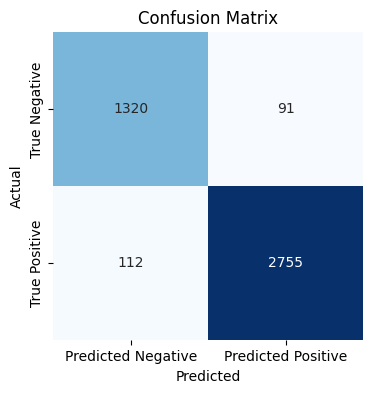

(0.9525479195885928,
 np.float64(0.9482207539198836),
 np.float64(0.9609347750261598),
 np.float64(0.9355067328136074))

In [ ]:
# Similarity test for train_set
evaluation(pairedLabels[:, 0], train_pred)

## validation

#### RF

In [ ]:
test_labels = np.asarray(test_labels)

Accuracy:  0.6666666666666666
ROC-AUC:  0.6666666666666667
Sensitivity:  0.8333333333333334
Specificity:  0.5


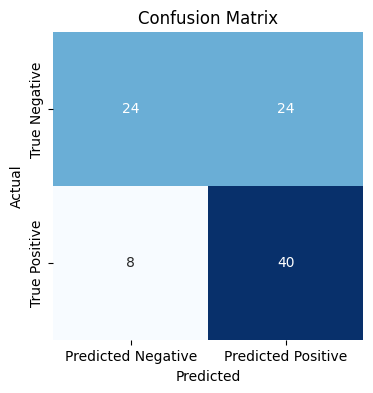

In [ ]:
acc, auc, sen, spc = evaluation(test_labels[:, 1], predict_RF)

In [ ]:
rf_acc.append(acc)
rf_auc.append(auc)
rf_sen.append(sen)
rf_spc.append(spc)

In [ ]:
print(rf_acc)
print(rf_auc)
print(rf_sen)
print(rf_spc)

[0.6666666666666666]
[np.float64(0.6666666666666667)]
[np.float64(0.8333333333333334)]
[np.float64(0.5)]


#### SVM

Accuracy:  0.625
ROC-AUC:  0.625
Sensitivity:  0.8958333333333334
Specificity:  0.3541666666666667


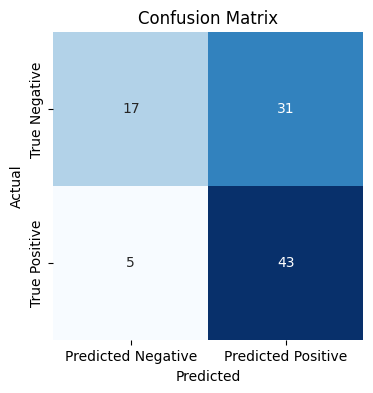

In [ ]:
acc, auc, sen, spc = evaluation(test_labels[:, 1], predict_SVM)

In [ ]:
svm_acc.append(acc)
svm_auc.append(auc)
svm_sen.append(sen)
svm_spc.append(spc)

In [ ]:
print(svm_acc)
print(svm_auc)
print(svm_sen)
print(svm_spc)

[0.625]
[np.float64(0.625)]
[np.float64(0.8958333333333334)]
[np.float64(0.3541666666666667)]


#### XGBoost

Accuracy:  0.7604166666666666
ROC-AUC:  0.7604166666666667
Sensitivity:  0.8958333333333334
Specificity:  0.625


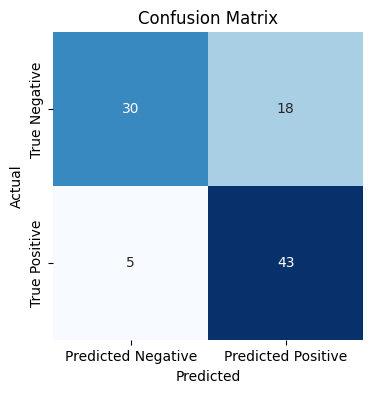

In [ ]:
acc, auc, sen, spc = evaluation(test_labels[:, 1], predict_XGB)

In [ ]:
xgb_acc.append(acc)
xgb_auc.append(auc)
xgb_sen.append(sen)
xgb_spc.append(spc)

In [ ]:
print(xgb_acc)
print(xgb_auc)
print(xgb_sen)
print(xgb_spc)

[0.7604166666666666]
[np.float64(0.7604166666666667)]
[np.float64(0.8958333333333334)]
[np.float64(0.625)]


#### Triplet NN

In [ ]:
test_labels = np.asarray(test_labels)
train_labels = np.asarray(train_labels)

In [ ]:
# splitting external_test_set to set of susceptible and resistant ones:
x0_test, x1_test = RS_splitter(test_set, test_labels[:, 1])

In [ ]:
print(len(x0_test))
print(len(x0_test[0]))
print(len(x1_test))
print(len(x1_test[0]))

48
399
48
399


In [ ]:
x0_train, x1_train = RS_splitter(train_set, train_labels[:, 1])

In [ ]:
print(len(x0_train))
print(len(x0_train[0]))
print(len(x1_train))
print(len(x1_train[0]))

89
399
222
399


In [ ]:
x0_train = np.asarray(x0_train)
x1_train = np.asarray(x1_train)

In [ ]:
test_labels = []  # True labels for test samples.
aggre_preds = [] # Aggregated pred values for each sample, by DefineTest2 func.
internal_labels = [] # Labels form ExternalTest2 for internal test
internal_preds = [] # internal_labels corresponding predictions


for i in x0_test:                     #x0_test, x1_test, x0_train, x1_train
  data, labels, indexSample = ExternalTest([i], [], x0_train, x1_train) # makes i couple with x0_train & x1_train
  internal_labels += labels.tolist()
  predd = siamese_net.predict([[data[:, :96],
                           data[:, 96:(96+96)]],
                           data[:, (96+96):]], verbose=0)
  internal_preds += [i[0] for i in predd.tolist()]
  y_pred, label = DefineTest2([i], [], indexSample, predd)
  aggre_preds.append(y_pred[0][0]) # y_pred ---> [array([0.5], dtype=float32)]
  test_labels.append(label[0])


for i in x1_test:
  data, labels, indexSample = ExternalTest([], [i], x0_train, x1_train)
  internal_labels += labels.tolist()
  predd = siamese_net.predict([[data[:, :96],
                           data[:, 96:(96+96)]],
                           data[:, (96+96):]], verbose=0)
  internal_preds += [i[0] for i in predd.tolist()]
  y_pred, label = DefineTest2([], [i], indexSample, predd)
  aggre_preds.append(y_pred[0][0])
  test_labels.append(label[0])

##### TSA_Net evaluation

(Similarity test)

Accuracy:  0.6844229217110573
ROC-AUC:  0.6844229217110573
Sensitivity:  0.7175141242937854
Specificity:  0.6513317191283293


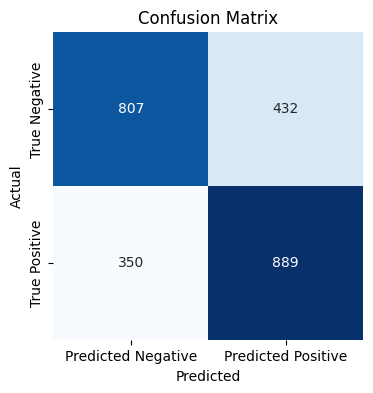

In [ ]:
acc, auc, sen, spc = evaluation(internal_labels, internal_preds)

In [ ]:
sim_acc.append(acc)
sim_auc.append(auc)
sim_sen.append(sen)
sim_spc.append(spc)

In [ ]:
print(sim_acc)
print(sim_auc)
print(sim_sen)
print(sim_spc)

[0.6844229217110573]
[np.float64(0.6844229217110573)]
[np.float64(0.7175141242937854)]
[np.float64(0.6513317191283293)]


##### TripSimAcin_AMR evaluation

(Phenotype prediction test)

Accuracy:  0.71875
ROC-AUC:  0.71875
Sensitivity:  0.625
Specificity:  0.8125


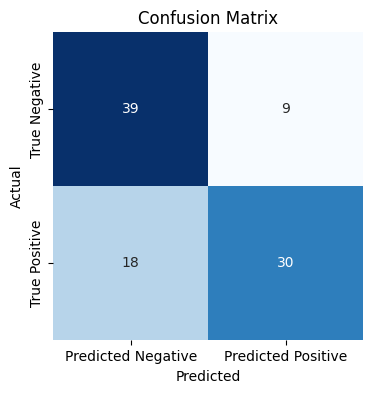

In [ ]:
acc, auc, sen, spc = evaluation(test_labels, aggre_preds)

In [ ]:
nn_acc.append(acc)
nn_auc.append(auc)
nn_sen.append(sen)
nn_spc.append(spc)

In [ ]:
print(nn_acc)
print(nn_auc)
print(nn_sen)
print(nn_spc)

[0.71875]
[np.float64(0.71875)]
[np.float64(0.625)]
[np.float64(0.8125)]


# Round 2
random state 0

In [ ]:
# Splitting data
train_set, test_set, train_labels, test_labels = balanced_train_test_split(orig_data, orig_labels, drugs, 5, 0)

3 28
for drug  cefotaxime # of train samples:  29
for drug  cefotaxime # of test samples:  2
10 31
for drug  ciprofloxacin # of train samples:  31
for drug  ciprofloxacin # of test samples:  10
26 16
for drug  imipenem # of train samples:  32
for drug  imipenem # of test samples:  10
13 27
for drug  ceftazidime # of train samples:  30
for drug  ceftazidime # of test samples:  10
11 11
for drug  doripenem # of train samples:  12
for drug  doripenem # of test samples:  10
2 30
for drug  ceftriaxone # of train samples:  30
for drug  ceftriaxone # of test samples:  2
6 6
for drug  moxifloxacin # of train samples:  6
for drug  moxifloxacin # of test samples:  6
15 17
for drug  meropenem # of train samples:  22
for drug  meropenem # of test samples:  10
13 25
for drug  levofloxacin # of train samples:  28
for drug  levofloxacin # of test samples:  10
12 24
for drug  tetracycline # of train samples:  26
for drug  tetracycline # of test samples:  10
20 21
for drug  amikacin # of train samples:

In [ ]:
triplet, pairedLabels =  make_balanced_triplets(train_set, train_labels, drugs, 400)

In [ ]:
train_labels = np.asarray(train_labels)
pairedLabels = np.asarray(pairedLabels)

### Training

#### Random Forest (RF)

In [ ]:
model = RandomForestClassifier(n_estimators=100).fit(train_set, train_labels[:, 1])
predict_RF = model.predict(test_set)

#### SVM

In [ ]:
model = SVC(kernel='poly').fit(train_set, train_labels[:, 1])
predict_SVM = model.predict(test_set)

#### XGBoost

In [ ]:
model = xgboost.XGBClassifier().fit(train_set, train_labels[:, 1])
predict_XGB = model.predict(test_set)

#### Triplet NN

In [ ]:
input_shape1 = (96,)
input_shape2 = (96,)
input_shape3 = (303,)

In [ ]:
siamese_net = create_siamese_model(input_shape1, input_shape2, input_shape3)

In [ ]:
triplet = np.asarray(triplet)

In [ ]:
triplet.shape

(4278, 495)

In [ ]:
pairedLabels = np.asarray(pairedLabels)

In [ ]:
pairedLabels.shape

In [ ]:
num_epochs=10
history=History()
siamese_net = create_siamese_model(input_shape1, input_shape2, input_shape3)

print("Round: 1 ---> 1-10")
history = siamese_net.fit([[triplet[:, :96],
                           triplet[:, 96:(96+96)]],
                           triplet[:, (96+96):]], pairedLabels[:, 0],
                          epochs=num_epochs, batch_size=64, verbose=1, callbacks=history)

for i in range(20-1):
  print("Round: ", i+2, '--->', (i+1)*10+1, '-', (i+2)*10)

  triplet, pairedLabels =  make_balanced_triplets(train_set, train_labels, drugs, 400)

  history = siamese_net.fit([[triplet[:, :96],
                           triplet[:, 96:(96+96)]],
                           triplet[:, (96+96):]], pairedLabels[:, 0],
                          epochs=num_epochs, batch_size=64, verbose=1, callbacks=history)


In [ ]:
train_pred = siamese_net.predict([[triplet[:, :96],
                           triplet[:, 96:(96+96)]],
                           triplet[:, (96+96):]])

Accuracy:  0.9593267882187938
ROC-AUC:  0.9617364387688837
Sensitivity:  0.9546564352982211
Specificity:  0.9688164422395464


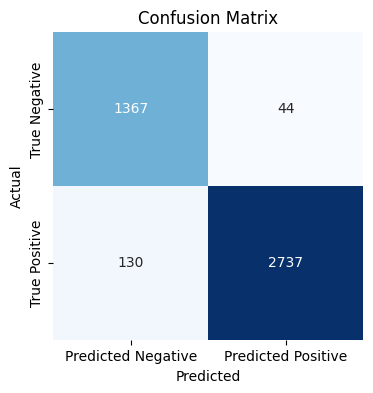

(0.9593267882187938,
 np.float64(0.9617364387688837),
 np.float64(0.9546564352982211),
 np.float64(0.9688164422395464))

In [ ]:
# Similarity test for train_set
evaluation(pairedLabels[:, 0], train_pred)

## Validation

#### RF

In [ ]:
test_labels = np.asarray(test_labels)

Accuracy:  0.71875
ROC-AUC:  0.7187499999999999
Sensitivity:  0.7916666666666666
Specificity:  0.6458333333333334


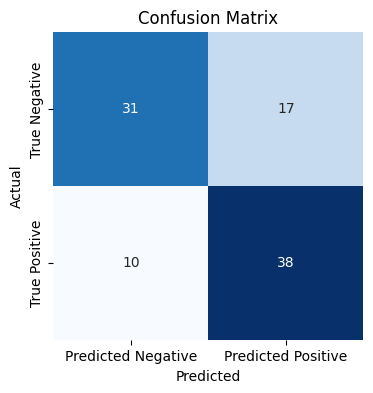

In [ ]:
acc, auc, sen, spc = evaluation(test_labels[:, 1], predict_RF)

In [ ]:
rf_acc.append(acc)
rf_auc.append(auc)
rf_sen.append(sen)
rf_spc.append(spc)

In [ ]:
print(rf_acc)
print(rf_auc)
print(rf_sen)
print(rf_spc)

[0.6666666666666666, 0.71875]
[np.float64(0.6666666666666667), np.float64(0.7187499999999999)]
[np.float64(0.8333333333333334), np.float64(0.7916666666666666)]
[np.float64(0.5), np.float64(0.6458333333333334)]


#### SVM

Accuracy:  0.6458333333333334
ROC-AUC:  0.6458333333333333
Sensitivity:  0.9166666666666666
Specificity:  0.375


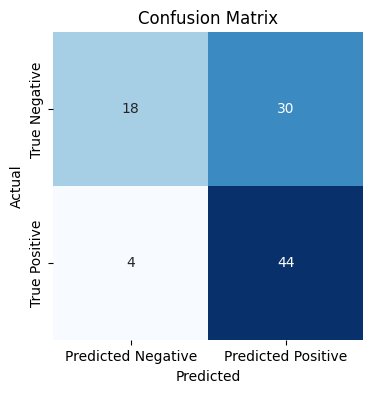

In [ ]:
acc, auc, sen, spc = evaluation(test_labels[:, 1], predict_SVM)

In [ ]:
svm_acc.append(acc)
svm_auc.append(auc)
svm_sen.append(sen)
svm_spc.append(spc)

In [ ]:
print(svm_acc)
print(svm_auc)
print(svm_sen)
print(svm_spc)

[0.625, 0.6458333333333334]
[np.float64(0.625), np.float64(0.6458333333333333)]
[np.float64(0.8958333333333334), np.float64(0.9166666666666666)]
[np.float64(0.3541666666666667), np.float64(0.375)]


#### XGBoost

Accuracy:  0.8020833333333334
ROC-AUC:  0.8020833333333333
Sensitivity:  0.9166666666666666
Specificity:  0.6875


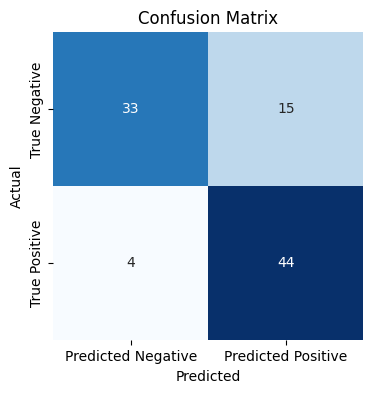

In [ ]:
acc, auc, sen, spc = evaluation(test_labels[:, 1], predict_XGB)

In [ ]:
xgb_acc.append(acc)
xgb_auc.append(auc)
xgb_sen.append(sen)
xgb_spc.append(spc)

In [ ]:
print(xgb_acc)
print(xgb_auc)
print(xgb_sen)
print(xgb_spc)

[0.7604166666666666, 0.8020833333333334]
[np.float64(0.7604166666666667), np.float64(0.8020833333333333)]
[np.float64(0.8958333333333334), np.float64(0.9166666666666666)]
[np.float64(0.625), np.float64(0.6875)]


#### Triplet NN

In [ ]:
test_labels = np.asarray(test_labels)
train_labels = np.asarray(train_labels)

In [ ]:
# splitting external_test_set to set of susceptible and resistant ones:
x0_test, x1_test = RS_splitter(test_set, test_labels[:, 1])

In [ ]:
print(len(x0_test))
print(len(x0_test[0]))
print(len(x1_test))
print(len(x1_test[0]))

48
399
48
399


In [ ]:
x0_train, x1_train = RS_splitter(train_set, train_labels[:, 1])

In [ ]:
print(len(x0_train))
print(len(x0_train[0]))
print(len(x1_train))
print(len(x1_train[0]))

89
399
222
399


In [ ]:
x0_train = np.asarray(x0_train)
x1_train = np.asarray(x1_train)

In [ ]:
test_labels = []  # True labels for test samples.
aggre_preds = [] # Aggregated pred values for each sample, by DefineTest2 func.
internal_labels = [] # Labels form ExternalTest2 for internal test
internal_preds = [] # internal_labels corresponding predictions


for i in x0_test:                     #x0_test, x1_test, x0_train, x1_train
  data, labels, indexSample = ExternalTest([i], [], x0_train, x1_train) # makes i couple with x0_train & x1_train
  internal_labels += labels.tolist()
  predd = siamese_net.predict([[data[:, :96],
                           data[:, 96:(96+96)]],
                           data[:, (96+96):]], verbose=0)
  internal_preds += [i[0] for i in predd.tolist()]
  y_pred, label = DefineTest2([i], [], indexSample, predd)
  aggre_preds.append(y_pred[0][0]) # y_pred ---> [array([0.5], dtype=float32)]
  test_labels.append(label[0])


for i in x1_test:
  data, labels, indexSample = ExternalTest([], [i], x0_train, x1_train)
  internal_labels += labels.tolist()
  predd = siamese_net.predict([[data[:, :96],
                           data[:, 96:(96+96)]],
                           data[:, (96+96):]], verbose=0)
  internal_preds += [i[0] for i in predd.tolist()]
  y_pred, label = DefineTest2([], [i], indexSample, predd)
  aggre_preds.append(y_pred[0][0])
  test_labels.append(label[0])

##### TSA_Net evaluation

(Similarity test)

Accuracy:  0.784503631961259
ROC-AUC:  0.784503631961259
Sensitivity:  0.8192090395480226
Specificity:  0.7497982243744956


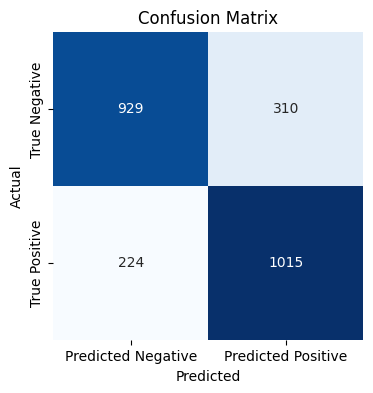

In [ ]:
acc, auc, sen, spc = evaluation(internal_labels, internal_preds)

In [ ]:
sim_acc.append(acc)
sim_auc.append(auc)
sim_sen.append(sen)
sim_spc.append(spc)

In [ ]:
print(sim_acc)
print(sim_auc)
print(sim_sen)
print(sim_spc)

[0.6844229217110573, 0.784503631961259]
[np.float64(0.6844229217110573), np.float64(0.784503631961259)]
[np.float64(0.7175141242937854), np.float64(0.8192090395480226)]
[np.float64(0.6513317191283293), np.float64(0.7497982243744956)]


##### TripSimAcin_AMR evaluation

(Phenotype prediction test)

Accuracy:  0.8333333333333334
ROC-AUC:  0.8333333333333334
Sensitivity:  0.875
Specificity:  0.7916666666666666


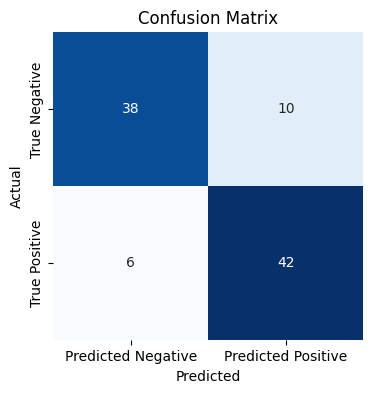

In [ ]:
acc, auc, sen, spc = evaluation(test_labels, aggre_preds)

In [ ]:
nn_acc.append(acc)
nn_auc.append(auc)
nn_sen.append(sen)
nn_spc.append(spc)

In [ ]:
print(nn_acc)
print(nn_auc)
print(nn_sen)
print(nn_spc)

[0.71875, 0.8333333333333334]
[np.float64(0.71875), np.float64(0.8333333333333334)]
[np.float64(0.625), np.float64(0.875)]
[np.float64(0.8125), np.float64(0.7916666666666666)]


# Round 3
random state: 123

In [ ]:
# Splitting data
train_set, test_set, train_labels, test_labels = balanced_train_test_split(orig_data, orig_labels, drugs, 5, 123)

3 28
for drug  cefotaxime # of train samples:  29
for drug  cefotaxime # of test samples:  2
10 31
for drug  ciprofloxacin # of train samples:  31
for drug  ciprofloxacin # of test samples:  10
26 16
for drug  imipenem # of train samples:  32
for drug  imipenem # of test samples:  10
13 27
for drug  ceftazidime # of train samples:  30
for drug  ceftazidime # of test samples:  10
11 11
for drug  doripenem # of train samples:  12
for drug  doripenem # of test samples:  10
2 30
for drug  ceftriaxone # of train samples:  30
for drug  ceftriaxone # of test samples:  2
6 6
for drug  moxifloxacin # of train samples:  6
for drug  moxifloxacin # of test samples:  6
15 17
for drug  meropenem # of train samples:  22
for drug  meropenem # of test samples:  10
13 25
for drug  levofloxacin # of train samples:  28
for drug  levofloxacin # of test samples:  10
12 24
for drug  tetracycline # of train samples:  26
for drug  tetracycline # of test samples:  10
20 21
for drug  amikacin # of train samples:

In [ ]:
triplet, pairedLabels =  make_balanced_triplets(train_set, train_labels, drugs, 400)

In [ ]:
train_labels = np.asarray(train_labels)
pairedLabels = np.asarray(pairedLabels)

### Training

#### Random Forest (RF)

In [ ]:
model = RandomForestClassifier(n_estimators=100).fit(train_set, train_labels[:, 1])
predict_RF = model.predict(test_set)

#### SVM

In [ ]:
model = SVC(kernel='poly').fit(train_set, train_labels[:, 1])
predict_SVM = model.predict(test_set)

#### XGBoost

In [ ]:
model = xgboost.XGBClassifier().fit(train_set, train_labels[:, 1])
predict_XGB = model.predict(test_set)

#### Triplet NN

In [ ]:
input_shape1 = (96,)
input_shape2 = (96,)
input_shape3 = (303,)

In [ ]:
siamese_net = create_siamese_model(input_shape1, input_shape2, input_shape3)

In [ ]:
triplet = np.asarray(triplet)

In [ ]:
triplet.shape

(4278, 495)

In [ ]:
pairedLabels = np.asarray(pairedLabels)

In [ ]:
pairedLabels.shape

(4278, 2)

In [ ]:
num_epochs=10
history=History()
siamese_net = create_siamese_model(input_shape1, input_shape2, input_shape3)

print("Round: 1 ---> 1-10")
history = siamese_net.fit([[triplet[:, :96],
                           triplet[:, 96:(96+96)]],
                           triplet[:, (96+96):]], pairedLabels[:, 0],
                          epochs=num_epochs, batch_size=64, verbose=1, callbacks=history)

for i in range(20-1):
  print("Round: ", i+2, '--->', (i+1)*10+1, '-', (i+2)*10)

  triplet, pairedLabels =  make_balanced_triplets(train_set, train_labels, drugs, 400)

  history = siamese_net.fit([[triplet[:, :96],
                           triplet[:, 96:(96+96)]],
                           triplet[:, (96+96):]], pairedLabels[:, 0],
                          epochs=num_epochs, batch_size=64, verbose=1, callbacks=history)

In [ ]:
train_pred = siamese_net.predict([[triplet[:, :96],
                           triplet[:, 96:(96+96)]],
                           triplet[:, (96+96):]])

Accuracy:  0.9831697054698457
ROC-AUC:  0.9822244722751157
Sensitivity:  0.9850017439832578
Specificity:  0.9794472005669738


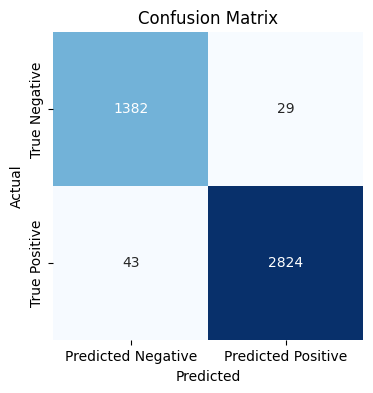

(0.9831697054698457,
 np.float64(0.9822244722751157),
 np.float64(0.9850017439832578),
 np.float64(0.9794472005669738))

In [ ]:
# Similarity test for train_set
evaluation(pairedLabels[:, 0], train_pred)

## Validation

#### RF

In [ ]:
test_labels = np.asarray(test_labels)

Accuracy:  0.6666666666666666
ROC-AUC:  0.6666666666666667
Sensitivity:  0.7708333333333334
Specificity:  0.5625


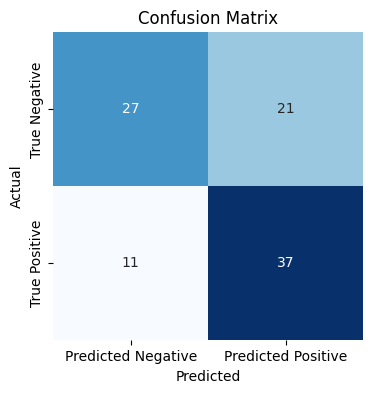

In [ ]:
acc, auc, sen, spc = evaluation(test_labels[:, 1], predict_RF)

In [ ]:
rf_acc.append(acc)
rf_auc.append(auc)
rf_sen.append(sen)
rf_spc.append(spc)

In [ ]:
print(rf_acc)
print(rf_auc)
print(rf_sen)
print(rf_spc)

[0.6666666666666666, 0.71875, 0.6666666666666666]
[np.float64(0.6666666666666667), np.float64(0.7187499999999999), np.float64(0.6666666666666667)]
[np.float64(0.8333333333333334), np.float64(0.7916666666666666), np.float64(0.7708333333333334)]
[np.float64(0.5), np.float64(0.6458333333333334), np.float64(0.5625)]


#### SVM

Accuracy:  0.6041666666666666
ROC-AUC:  0.6041666666666666
Sensitivity:  0.9166666666666666
Specificity:  0.2916666666666667


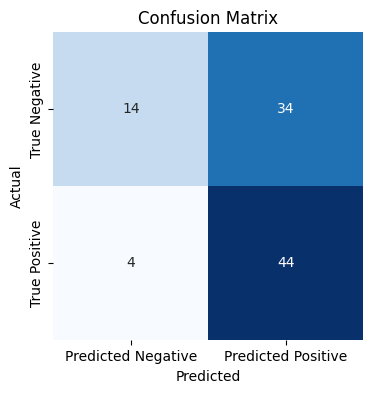

In [ ]:
acc, auc, sen, spc = evaluation(test_labels[:, 1], predict_SVM)

In [ ]:
svm_acc.append(acc)
svm_auc.append(auc)
svm_sen.append(sen)
svm_spc.append(spc)

In [ ]:
print(svm_acc)
print(svm_auc)
print(svm_sen)
print(svm_spc)

[0.625, 0.6458333333333334, 0.6041666666666666]
[np.float64(0.625), np.float64(0.6458333333333333), np.float64(0.6041666666666666)]
[np.float64(0.8958333333333334), np.float64(0.9166666666666666), np.float64(0.9166666666666666)]
[np.float64(0.3541666666666667), np.float64(0.375), np.float64(0.2916666666666667)]


#### XGBoost

Accuracy:  0.71875
ROC-AUC:  0.7187499999999999
Sensitivity:  0.9166666666666666
Specificity:  0.5208333333333334


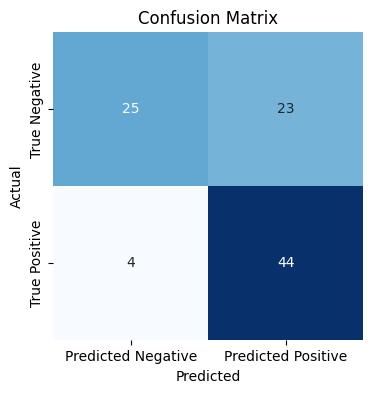

In [ ]:
acc, auc, sen, spc = evaluation(test_labels[:, 1], predict_XGB)

In [ ]:
xgb_acc.append(acc)
xgb_auc.append(auc)
xgb_sen.append(sen)
xgb_spc.append(spc)

In [ ]:
print(xgb_acc)
print(xgb_auc)
print(xgb_sen)
print(xgb_spc)

[0.7604166666666666, 0.8020833333333334, 0.71875]
[np.float64(0.7604166666666667), np.float64(0.8020833333333333), np.float64(0.7187499999999999)]
[np.float64(0.8958333333333334), np.float64(0.9166666666666666), np.float64(0.9166666666666666)]
[np.float64(0.625), np.float64(0.6875), np.float64(0.5208333333333334)]


#### Triplet NN

In [ ]:
test_labels = np.asarray(test_labels)
train_labels = np.asarray(train_labels)

In [ ]:
# splitting external_test_set to set of susceptible and resistant ones:
x0_test, x1_test = RS_splitter(test_set, test_labels[:, 1])

In [ ]:
print(len(x0_test))
print(len(x0_test[0]))
print(len(x1_test))
print(len(x1_test[0]))

48
399
48
399


In [ ]:
x0_train, x1_train = RS_splitter(train_set, train_labels[:, 1])

In [ ]:
print(len(x0_train))
print(len(x0_train[0]))
print(len(x1_train))
print(len(x1_train[0]))

89
399
222
399


In [ ]:
x0_train = np.asarray(x0_train)
x1_train = np.asarray(x1_train)

In [ ]:
test_labels = []  # True labels for test samples.
aggre_preds = [] # Aggregated pred values for each sample, by DefineTest2 func.
internal_labels = [] # Labels form ExternalTest2 for internal test
internal_preds = [] # internal_labels corresponding predictions


for i in x0_test:                     #x0_test, x1_test, x0_train, x1_train
  data, labels, indexSample = ExternalTest([i], [], x0_train, x1_train) # makes i couple with x0_train & x1_train
  internal_labels += labels.tolist()
  predd = siamese_net.predict([[data[:, :96],
                           data[:, 96:(96+96)]],
                           data[:, (96+96):]], verbose=0)
  internal_preds += [i[0] for i in predd.tolist()]
  y_pred, label = DefineTest2([i], [], indexSample, predd)
  aggre_preds.append(y_pred[0][0]) # y_pred ---> [array([0.5], dtype=float32)]
  test_labels.append(label[0])


for i in x1_test:
  data, labels, indexSample = ExternalTest([], [i], x0_train, x1_train)
  internal_labels += labels.tolist()
  predd = siamese_net.predict([[data[:, :96],
                           data[:, 96:(96+96)]],
                           data[:, (96+96):]], verbose=0)
  internal_preds += [i[0] for i in predd.tolist()]
  y_pred, label = DefineTest2([], [i], indexSample, predd)
  aggre_preds.append(y_pred[0][0])
  test_labels.append(label[0])

##### TSA_Net evaluation

(Similarity test)

Accuracy:  0.7566585956416465
ROC-AUC:  0.7566585956416465
Sensitivity:  0.8087167070217918
Specificity:  0.7046004842615012


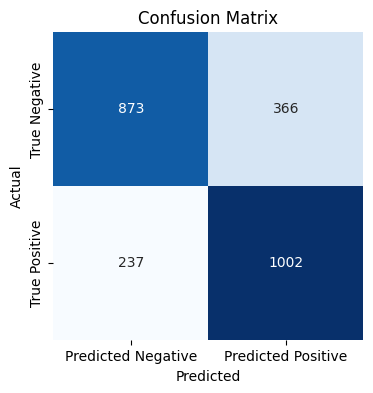

In [ ]:
acc, auc, sen, spc = evaluation(internal_labels, internal_preds)

In [ ]:
sim_acc.append(acc)
sim_auc.append(auc)
sim_sen.append(sen)
sim_spc.append(spc)

In [ ]:
print(sim_acc)
print(sim_auc)
print(sim_sen)
print(sim_spc)

[0.6844229217110573, 0.784503631961259, 0.7566585956416465]
[np.float64(0.6844229217110573), np.float64(0.784503631961259), np.float64(0.7566585956416465)]
[np.float64(0.7175141242937854), np.float64(0.8192090395480226), np.float64(0.8087167070217918)]
[np.float64(0.6513317191283293), np.float64(0.7497982243744956), np.float64(0.7046004842615012)]


##### TripSimAcin_AMR evaluation

(Phenotype prediction test)

Accuracy:  0.7916666666666666
ROC-AUC:  0.7916666666666666
Sensitivity:  0.8333333333333334
Specificity:  0.75


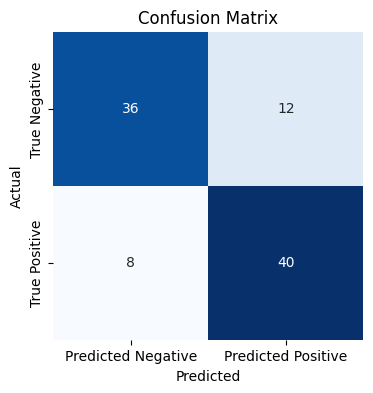

In [ ]:
acc, auc, sen, spc = evaluation(test_labels, aggre_preds)

In [ ]:
nn_acc.append(acc)
nn_auc.append(auc)
nn_sen.append(sen)
nn_spc.append(spc)

In [ ]:
print(nn_acc)
print(nn_auc)
print(nn_sen)
print(nn_spc)

[0.71875, 0.8333333333333334, 0.7916666666666666]
[np.float64(0.71875), np.float64(0.8333333333333334), np.float64(0.7916666666666666)]
[np.float64(0.625), np.float64(0.875), np.float64(0.8333333333333334)]
[np.float64(0.8125), np.float64(0.7916666666666666), np.float64(0.75)]


# Round 4
random state: 777

In [ ]:
# Splitting data
train_set, test_set, train_labels, test_labels = balanced_train_test_split(orig_data, orig_labels, drugs, 5, 777)

3 28
for drug  cefotaxime # of train samples:  29
for drug  cefotaxime # of test samples:  2
10 31
for drug  ciprofloxacin # of train samples:  31
for drug  ciprofloxacin # of test samples:  10
26 16
for drug  imipenem # of train samples:  32
for drug  imipenem # of test samples:  10
13 27
for drug  ceftazidime # of train samples:  30
for drug  ceftazidime # of test samples:  10
11 11
for drug  doripenem # of train samples:  12
for drug  doripenem # of test samples:  10
2 30
for drug  ceftriaxone # of train samples:  30
for drug  ceftriaxone # of test samples:  2
6 6
for drug  moxifloxacin # of train samples:  6
for drug  moxifloxacin # of test samples:  6
15 17
for drug  meropenem # of train samples:  22
for drug  meropenem # of test samples:  10
13 25
for drug  levofloxacin # of train samples:  28
for drug  levofloxacin # of test samples:  10
12 24
for drug  tetracycline # of train samples:  26
for drug  tetracycline # of test samples:  10
20 21
for drug  amikacin # of train samples:

In [ ]:
triplet, pairedLabels =  make_balanced_triplets(train_set, train_labels, drugs, 400)

In [ ]:
train_labels = np.asarray(train_labels)
pairedLabels = np.asarray(pairedLabels)

### Training

#### Random Forest (RF)

In [ ]:
model = RandomForestClassifier(n_estimators=100).fit(train_set, train_labels[:, 1])
predict_RF = model.predict(test_set)

#### SVM

In [ ]:
model = SVC(kernel='poly').fit(train_set, train_labels[:, 1])
predict_SVM = model.predict(test_set)

#### XGBoost

In [ ]:
model = xgboost.XGBClassifier().fit(train_set, train_labels[:, 1])
predict_XGB = model.predict(test_set)

#### Triplet NN

In [ ]:
input_shape1 = (96,)
input_shape2 = (96,)
input_shape3 = (303,)

In [ ]:
siamese_net = create_siamese_model(input_shape1, input_shape2, input_shape3)

In [ ]:
triplet = np.asarray(triplet)

In [ ]:
triplet.shape

(4278, 495)

In [ ]:
pairedLabels = np.asarray(pairedLabels)

In [ ]:
pairedLabels.shape

(4278, 2)

In [ ]:
num_epochs=10
history=History()
siamese_net = create_siamese_model(input_shape1, input_shape2, input_shape3)

print("Round: 1 ---> 1-10")
history = siamese_net.fit([[triplet[:, :96],
                           triplet[:, 96:(96+96)]],
                           triplet[:, (96+96):]], pairedLabels[:, 0],
                          epochs=num_epochs, batch_size=64, verbose=1, callbacks=history)

for i in range(20-1):
  print("Round: ", i+2, '--->', (i+1)*10+1, '-', (i+2)*10)

  triplet, pairedLabels =  make_balanced_triplets(train_set, train_labels, drugs, 400)

  history = siamese_net.fit([[triplet[:, :96],
                           triplet[:, 96:(96+96)]],
                           triplet[:, (96+96):]], pairedLabels[:, 0],
                          epochs=num_epochs, batch_size=64, verbose=1, callbacks=history)


In [ ]:
train_pred = siamese_net.predict([[triplet[:, :96],
                           triplet[:, 96:(96+96)]],
                           triplet[:, (96+96):]])

Accuracy:  0.9630668536699393
ROC-AUC:  0.9537291948730107
Sensitivity:  0.9811649808161842
Specificity:  0.926293408929837


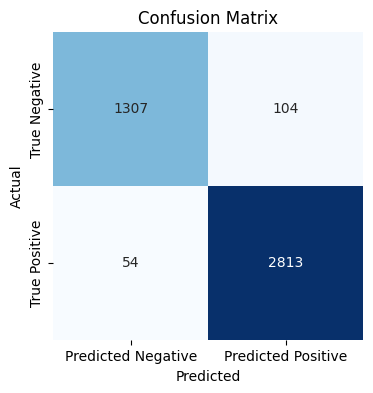

(0.9630668536699393,
 np.float64(0.9537291948730107),
 np.float64(0.9811649808161842),
 np.float64(0.926293408929837))

In [ ]:
# Similarity test for train_set
evaluation(pairedLabels[:, 0], train_pred)

## Validation

#### RF

In [ ]:
test_labels = np.asarray(test_labels)

Accuracy:  0.6666666666666666
ROC-AUC:  0.6666666666666667
Sensitivity:  0.8333333333333334
Specificity:  0.5


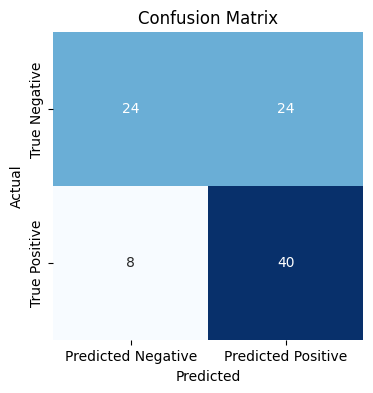

In [ ]:
acc, auc, sen, spc = evaluation(test_labels[:, 1], predict_RF)

In [ ]:
rf_acc.append(acc)
rf_auc.append(auc)
rf_sen.append(sen)
rf_spc.append(spc)

In [ ]:
print(rf_acc)
print(rf_auc)
print(rf_sen)
print(rf_spc)

[0.6666666666666666, 0.71875, 0.6666666666666666, 0.6666666666666666]
[np.float64(0.6666666666666667), np.float64(0.7187499999999999), np.float64(0.6666666666666667), np.float64(0.6666666666666667)]
[np.float64(0.8333333333333334), np.float64(0.7916666666666666), np.float64(0.7708333333333334), np.float64(0.8333333333333334)]
[np.float64(0.5), np.float64(0.6458333333333334), np.float64(0.5625), np.float64(0.5)]


#### SVM

Accuracy:  0.5833333333333334
ROC-AUC:  0.5833333333333333
Sensitivity:  0.9166666666666666
Specificity:  0.25


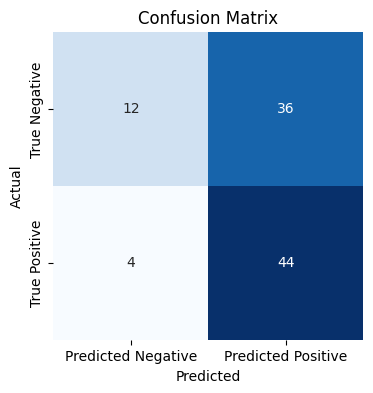

In [ ]:
acc, auc, sen, spc = evaluation(test_labels[:, 1], predict_SVM)

In [ ]:
svm_acc.append(acc)
svm_auc.append(auc)
svm_sen.append(sen)
svm_spc.append(spc)

In [ ]:
print(svm_acc)
print(svm_auc)
print(svm_sen)
print(svm_spc)

[0.625, 0.6458333333333334, 0.6041666666666666, 0.5833333333333334]
[np.float64(0.625), np.float64(0.6458333333333333), np.float64(0.6041666666666666), np.float64(0.5833333333333333)]
[np.float64(0.8958333333333334), np.float64(0.9166666666666666), np.float64(0.9166666666666666), np.float64(0.9166666666666666)]
[np.float64(0.3541666666666667), np.float64(0.375), np.float64(0.2916666666666667), np.float64(0.25)]


#### XGBoost

Accuracy:  0.7916666666666666
ROC-AUC:  0.7916666666666665
Sensitivity:  0.875
Specificity:  0.7083333333333334


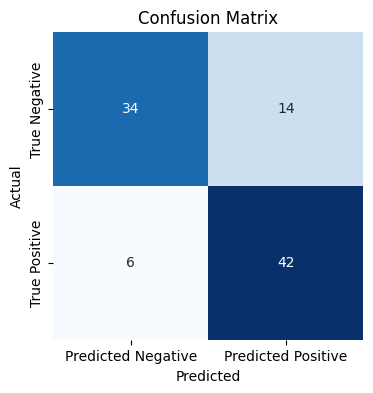

In [ ]:
acc, auc, sen, spc = evaluation(test_labels[:, 1], predict_XGB)

In [ ]:
xgb_acc.append(acc)
xgb_auc.append(auc)
xgb_sen.append(sen)
xgb_spc.append(spc)

In [ ]:
print(xgb_acc)
print(xgb_auc)
print(xgb_sen)
print(xgb_spc)

[0.7604166666666666, 0.8020833333333334, 0.71875, 0.7916666666666666]
[np.float64(0.7604166666666667), np.float64(0.8020833333333333), np.float64(0.7187499999999999), np.float64(0.7916666666666665)]
[np.float64(0.8958333333333334), np.float64(0.9166666666666666), np.float64(0.9166666666666666), np.float64(0.875)]
[np.float64(0.625), np.float64(0.6875), np.float64(0.5208333333333334), np.float64(0.7083333333333334)]


#### Triplet NN

In [ ]:
test_labels = np.asarray(test_labels)
train_labels = np.asarray(train_labels)

In [ ]:
# splitting external_test_set to set of susceptible and resistant ones:
x0_test, x1_test = RS_splitter(test_set, test_labels[:, 1])

In [ ]:
print(len(x0_test))
print(len(x0_test[0]))
print(len(x1_test))
print(len(x1_test[0]))

48
399
48
399


In [ ]:
x0_train, x1_train = RS_splitter(train_set, train_labels[:, 1])

In [ ]:
print(len(x0_train))
print(len(x0_train[0]))
print(len(x1_train))
print(len(x1_train[0]))

89
399
222
399


In [ ]:
x0_train = np.asarray(x0_train)
x1_train = np.asarray(x1_train)

In [ ]:
test_labels = []  # True labels for test samples.
aggre_preds = [] # Aggregated pred values for each sample, by DefineTest2 func.
internal_labels = [] # Labels form ExternalTest2 for internal test
internal_preds = [] # internal_labels corresponding predictions


for i in x0_test:                     #x0_test, x1_test, x0_train, x1_train
  data, labels, indexSample = ExternalTest([i], [], x0_train, x1_train) # makes i couple with x0_train & x1_train
  internal_labels += labels.tolist()
  predd = siamese_net.predict([[data[:, :96],
                           data[:, 96:(96+96)]],
                           data[:, (96+96):]], verbose=0)
  internal_preds += [i[0] for i in predd.tolist()]
  y_pred, label = DefineTest2([i], [], indexSample, predd)
  aggre_preds.append(y_pred[0][0]) # y_pred ---> [array([0.5], dtype=float32)]
  test_labels.append(label[0])


for i in x1_test:
  data, labels, indexSample = ExternalTest([], [i], x0_train, x1_train)
  internal_labels += labels.tolist()
  predd = siamese_net.predict([[data[:, :96],
                           data[:, 96:(96+96)]],
                           data[:, (96+96):]], verbose=0)
  internal_preds += [i[0] for i in predd.tolist()]
  y_pred, label = DefineTest2([], [i], indexSample, predd)
  aggre_preds.append(y_pred[0][0])
  test_labels.append(label[0])


##### TSA_Net evaluation

(Similarity test)

Accuracy:  0.7574656981436643
ROC-AUC:  0.757465698143664
Sensitivity:  0.837772397094431
Specificity:  0.6771589991928975


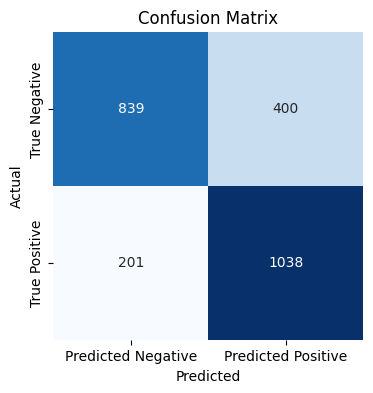

In [ ]:
acc, auc, sen, spc = evaluation(internal_labels, internal_preds)

In [ ]:
sim_acc.append(acc)
sim_auc.append(auc)
sim_sen.append(sen)
sim_spc.append(spc)

In [ ]:
print(sim_acc)
print(sim_auc)
print(sim_sen)
print(sim_spc)

[0.6844229217110573, 0.784503631961259, 0.7566585956416465, 0.7574656981436643]
[np.float64(0.6844229217110573), np.float64(0.784503631961259), np.float64(0.7566585956416465), np.float64(0.757465698143664)]
[np.float64(0.7175141242937854), np.float64(0.8192090395480226), np.float64(0.8087167070217918), np.float64(0.837772397094431)]
[np.float64(0.6513317191283293), np.float64(0.7497982243744956), np.float64(0.7046004842615012), np.float64(0.6771589991928975)]


##### TripSimAcin_AMR evaluation

(Phenotype prediction test)

Accuracy:  0.8020833333333334
ROC-AUC:  0.8020833333333333
Sensitivity:  0.7916666666666666
Specificity:  0.8125


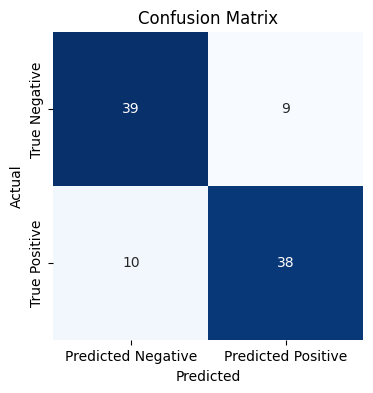

In [ ]:
acc, auc, sen, spc = evaluation(test_labels, aggre_preds)

In [ ]:
nn_acc.append(acc)
nn_auc.append(auc)
nn_sen.append(sen)
nn_spc.append(spc)

In [ ]:
print(nn_acc)
print(nn_auc)
print(nn_sen)
print(nn_spc)

[0.71875, 0.8333333333333334, 0.7916666666666666, 0.8020833333333334]
[np.float64(0.71875), np.float64(0.8333333333333334), np.float64(0.7916666666666666), np.float64(0.8020833333333333)]
[np.float64(0.625), np.float64(0.875), np.float64(0.8333333333333334), np.float64(0.7916666666666666)]
[np.float64(0.8125), np.float64(0.7916666666666666), np.float64(0.75), np.float64(0.8125)]


# Round 5
random state: 111

In [ ]:
# Splitting data
train_set, test_set, train_labels, test_labels = balanced_train_test_split(orig_data, orig_labels, drugs, 5, 111)

3 28
for drug  cefotaxime # of train samples:  29
for drug  cefotaxime # of test samples:  2
10 31
for drug  ciprofloxacin # of train samples:  31
for drug  ciprofloxacin # of test samples:  10
26 16
for drug  imipenem # of train samples:  32
for drug  imipenem # of test samples:  10
13 27
for drug  ceftazidime # of train samples:  30
for drug  ceftazidime # of test samples:  10
11 11
for drug  doripenem # of train samples:  12
for drug  doripenem # of test samples:  10
2 30
for drug  ceftriaxone # of train samples:  30
for drug  ceftriaxone # of test samples:  2
6 6
for drug  moxifloxacin # of train samples:  6
for drug  moxifloxacin # of test samples:  6
15 17
for drug  meropenem # of train samples:  22
for drug  meropenem # of test samples:  10
13 25
for drug  levofloxacin # of train samples:  28
for drug  levofloxacin # of test samples:  10
12 24
for drug  tetracycline # of train samples:  26
for drug  tetracycline # of test samples:  10
20 21
for drug  amikacin # of train samples:

In [ ]:
triplet, pairedLabels =  make_balanced_triplets(train_set, train_labels, drugs, 400)

In [ ]:
train_labels = np.asarray(train_labels)
pairedLabels = np.asarray(pairedLabels)

### Training

#### Random Forest (RF)

In [ ]:
model = RandomForestClassifier(n_estimators=100).fit(train_set, train_labels[:, 1])
predict_RF = model.predict(test_set)

#### SVM

In [ ]:
model = SVC(kernel='poly').fit(train_set, train_labels[:, 1])
predict_SVM = model.predict(test_set)

#### XGBoost

In [ ]:
model = xgboost.XGBClassifier().fit(train_set, train_labels[:, 1])
predict_XGB = model.predict(test_set)

#### Triplet NN

In [ ]:
input_shape1 = (96,)
input_shape2 = (96,)
input_shape3 = (303,)

In [ ]:
siamese_net = create_siamese_model(input_shape1, input_shape2, input_shape3)

In [ ]:
triplet = np.asarray(triplet)

In [ ]:
triplet.shape

(4278, 495)

In [ ]:
pairedLabels = np.asarray(pairedLabels)

In [ ]:
pairedLabels.shape

(4278, 2)

In [ ]:
num_epochs=10
history=History()
siamese_net = create_siamese_model(input_shape1, input_shape2, input_shape3)

print("Round: 1 ---> 1-10")
history = siamese_net.fit([[triplet[:, :96],
                           triplet[:, 96:(96+96)]],
                           triplet[:, (96+96):]], pairedLabels[:, 0],
                          epochs=num_epochs, batch_size=64, verbose=1, callbacks=history)

for i in range(20-1):
  print("Round: ", i+2, '--->', (i+1)*10+1, '-', (i+2)*10)

  triplet, pairedLabels =  make_balanced_triplets(train_set, train_labels, drugs, 400)

  history = siamese_net.fit([[triplet[:, :96],
                           triplet[:, 96:(96+96)]],
                           triplet[:, (96+96):]], pairedLabels[:, 0],
                          epochs=num_epochs, batch_size=64, verbose=1, callbacks=history)


In [ ]:
train_pred = siamese_net.predict([[triplet[:, :96],
                           triplet[:, 96:(96+96)]],
                           triplet[:, (96+96):]])

Accuracy:  0.9457690509583918
ROC-AUC:  0.9510814550184571
Sensitivity:  0.9354726194628532
Specificity:  0.966690290574061


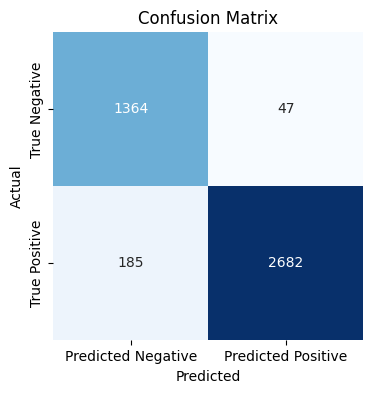

(0.9457690509583918,
 np.float64(0.9510814550184571),
 np.float64(0.9354726194628532),
 np.float64(0.966690290574061))

In [ ]:
# Similarity test for train_set
evaluation(pairedLabels[:, 0], train_pred)

## Validation

#### RF

In [ ]:
test_labels = np.asarray(test_labels)

Accuracy:  0.6979166666666666
ROC-AUC:  0.6979166666666666
Sensitivity:  0.875
Specificity:  0.5208333333333334


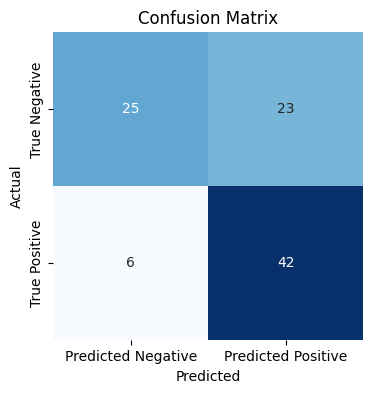

In [ ]:
acc, auc, sen, spc = evaluation(test_labels[:, 1], predict_RF)

In [ ]:
rf_acc.append(acc)
rf_auc.append(auc)
rf_sen.append(sen)
rf_spc.append(spc)

In [ ]:
print(rf_acc)
print(rf_auc)
print(rf_sen)
print(rf_spc)

[0.6666666666666666, 0.71875, 0.6666666666666666, 0.6666666666666666, 0.6979166666666666]
[np.float64(0.6666666666666667), np.float64(0.7187499999999999), np.float64(0.6666666666666667), np.float64(0.6666666666666667), np.float64(0.6979166666666666)]
[np.float64(0.8333333333333334), np.float64(0.7916666666666666), np.float64(0.7708333333333334), np.float64(0.8333333333333334), np.float64(0.875)]
[np.float64(0.5), np.float64(0.6458333333333334), np.float64(0.5625), np.float64(0.5), np.float64(0.5208333333333334)]


#### SVM

Accuracy:  0.59375
ROC-AUC:  0.59375
Sensitivity:  0.8958333333333334
Specificity:  0.2916666666666667


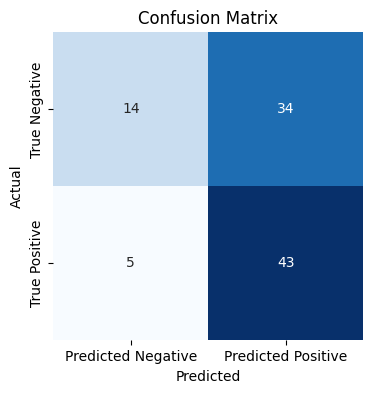

In [ ]:
acc, auc, sen, spc = evaluation(test_labels[:, 1], predict_SVM)

In [ ]:
svm_acc.append(acc)
svm_auc.append(auc)
svm_sen.append(sen)
svm_spc.append(spc)

In [ ]:
print(svm_acc)
print(svm_auc)
print(svm_sen)
print(svm_spc)

[0.625, 0.6458333333333334, 0.6041666666666666, 0.5833333333333334, 0.59375]
[np.float64(0.625), np.float64(0.6458333333333333), np.float64(0.6041666666666666), np.float64(0.5833333333333333), np.float64(0.59375)]
[np.float64(0.8958333333333334), np.float64(0.9166666666666666), np.float64(0.9166666666666666), np.float64(0.9166666666666666), np.float64(0.8958333333333334)]
[np.float64(0.3541666666666667), np.float64(0.375), np.float64(0.2916666666666667), np.float64(0.25), np.float64(0.2916666666666667)]


#### XGBoost

Accuracy:  0.84375
ROC-AUC:  0.84375
Sensitivity:  0.9375
Specificity:  0.75


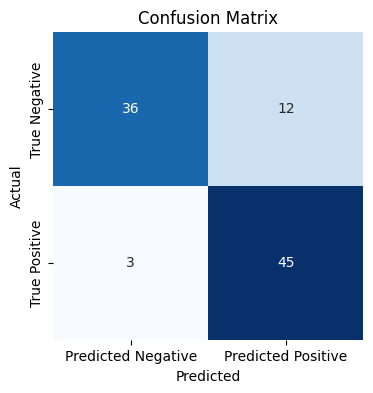

In [ ]:
acc, auc, sen, spc = evaluation(test_labels[:, 1], predict_XGB)

In [ ]:
xgb_acc.append(acc)
xgb_auc.append(auc)
xgb_sen.append(sen)
xgb_spc.append(spc)

In [ ]:
print(xgb_acc)
print(xgb_auc)
print(xgb_sen)
print(xgb_spc)

[0.7604166666666666, 0.8020833333333334, 0.71875, 0.7916666666666666, 0.84375]
[np.float64(0.7604166666666667), np.float64(0.8020833333333333), np.float64(0.7187499999999999), np.float64(0.7916666666666665), np.float64(0.84375)]
[np.float64(0.8958333333333334), np.float64(0.9166666666666666), np.float64(0.9166666666666666), np.float64(0.875), np.float64(0.9375)]
[np.float64(0.625), np.float64(0.6875), np.float64(0.5208333333333334), np.float64(0.7083333333333334), np.float64(0.75)]


#### Triplet NN

In [ ]:
test_labels = np.asarray(test_labels)
train_labels = np.asarray(train_labels)

In [ ]:
# splitting external_test_set to set of susceptible and resistant ones:
x0_test, x1_test = RS_splitter(test_set, test_labels[:, 1])

In [ ]:
print(len(x0_test))
print(len(x0_test[0]))
print(len(x1_test))
print(len(x1_test[0]))

48
399
48
399


In [ ]:
x0_train, x1_train = RS_splitter(train_set, train_labels[:, 1])

In [ ]:
print(len(x0_train))
print(len(x0_train[0]))
print(len(x1_train))
print(len(x1_train[0]))

89
399
222
399


In [ ]:
x0_train = np.asarray(x0_train)
x1_train = np.asarray(x1_train)

In [ ]:
test_labels = []  # True labels for test samples.
aggre_preds = [] # Aggregated pred values for each sample, by DefineTest2 func.
internal_labels = [] # Labels form ExternalTest2 for internal test
internal_preds = [] # internal_labels corresponding predictions


for i in x0_test:                     #x0_test, x1_test, x0_train, x1_train
  data, labels, indexSample = ExternalTest([i], [], x0_train, x1_train) # makes i couple with x0_train & x1_train
  internal_labels += labels.tolist()
  predd = siamese_net.predict([[data[:, :96],
                           data[:, 96:(96+96)]],
                           data[:, (96+96):]], verbose=0)
  internal_preds += [i[0] for i in predd.tolist()]
  y_pred, label = DefineTest2([i], [], indexSample, predd)
  aggre_preds.append(y_pred[0][0]) # y_pred ---> [array([0.5], dtype=float32)]
  test_labels.append(label[0])


for i in x1_test:
  data, labels, indexSample = ExternalTest([], [i], x0_train, x1_train)
  internal_labels += labels.tolist()
  predd = siamese_net.predict([[data[:, :96],
                           data[:, 96:(96+96)]],
                           data[:, (96+96):]], verbose=0)
  internal_preds += [i[0] for i in predd.tolist()]
  y_pred, label = DefineTest2([], [i], indexSample, predd)
  aggre_preds.append(y_pred[0][0])
  test_labels.append(label[0])

##### TSA_Net evaluation

(Similarity test)

Accuracy:  0.7631154156577885
ROC-AUC:  0.7631154156577886
Sensitivity:  0.7966101694915254
Specificity:  0.7296206618240516


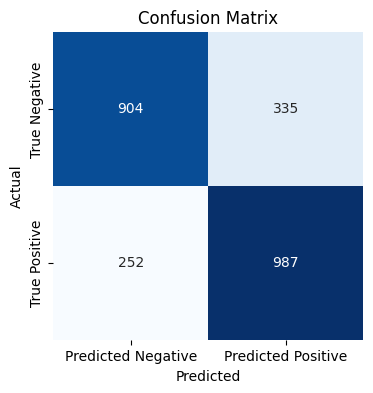

In [ ]:
acc, auc, sen, spc = evaluation(internal_labels, internal_preds)

In [ ]:
sim_acc.append(acc)
sim_auc.append(auc)
sim_sen.append(sen)
sim_spc.append(spc)

In [ ]:
print(sim_acc)
print(sim_auc)
print(sim_sen)
print(sim_spc)

[0.6844229217110573, 0.784503631961259, 0.7566585956416465, 0.7574656981436643, 0.7631154156577885]
[np.float64(0.6844229217110573), np.float64(0.784503631961259), np.float64(0.7566585956416465), np.float64(0.757465698143664), np.float64(0.7631154156577886)]
[np.float64(0.7175141242937854), np.float64(0.8192090395480226), np.float64(0.8087167070217918), np.float64(0.837772397094431), np.float64(0.7966101694915254)]
[np.float64(0.6513317191283293), np.float64(0.7497982243744956), np.float64(0.7046004842615012), np.float64(0.6771589991928975), np.float64(0.7296206618240516)]


##### TripSimAcin_AMR evaluation

(Phenotype prediction test)

Accuracy:  0.8333333333333334
ROC-AUC:  0.8333333333333334
Sensitivity:  0.9375
Specificity:  0.7291666666666666


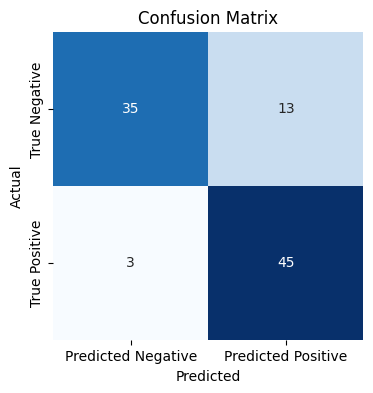

In [ ]:
acc, auc, sen, spc = evaluation(test_labels, aggre_preds)

In [ ]:
nn_acc.append(acc)
nn_auc.append(auc)
nn_sen.append(sen)
nn_spc.append(spc)

In [ ]:
print(nn_acc)
print(nn_auc)
print(nn_sen)
print(nn_spc)

[0.71875, 0.8333333333333334, 0.7916666666666666, 0.8020833333333334, 0.8333333333333334]
[np.float64(0.71875), np.float64(0.8333333333333334), np.float64(0.7916666666666666), np.float64(0.8020833333333333), np.float64(0.8333333333333334)]
[np.float64(0.625), np.float64(0.875), np.float64(0.8333333333333334), np.float64(0.7916666666666666), np.float64(0.9375)]
[np.float64(0.8125), np.float64(0.7916666666666666), np.float64(0.75), np.float64(0.8125), np.float64(0.7291666666666666)]


# Results

## RF

In [ ]:
print("Average accuracy: ", sum(rf_acc)/len(rf_acc))
print("Average AUC: ", sum(rf_auc)/len(rf_auc))
print("Average sensitivity: ", sum(rf_sen)/len(rf_sen))
print("Average specificity: ", sum(rf_spc)/len(rf_spc))

Average accuracy:  0.6833333333333333
Average AUC:  0.6833333333333333
Average sensitivity:  0.8208333333333334
Average specificity:  0.5458333333333334


## SVM

In [ ]:
print("Average accuracy: ", sum(svm_acc)/len(svm_acc))
print("Average AUC: ", sum(svm_auc)/len(svm_auc))
print("Average sensitivity: ", sum(svm_sen)/len(svm_sen))
print("Average specificity: ", sum(svm_spc)/len(svm_spc))

Average accuracy:  0.6104166666666667
Average AUC:  0.6104166666666666
Average sensitivity:  0.9083333333333332
Average specificity:  0.31250000000000006


## XGB

In [ ]:
print("Average accuracy: ", sum(xgb_acc)/len(xgb_acc))
print("Average AUC: ", sum(xgb_auc)/len(xgb_auc))
print("Average sensitivity: ", sum(xgb_sen)/len(xgb_sen))
print("Average specificity: ", sum(xgb_spc)/len(xgb_spc))

Average accuracy:  0.7833333333333333
Average AUC:  0.7833333333333333
Average sensitivity:  0.9083333333333332
Average specificity:  0.6583333333333334


## TripSimAcin_AMR

In [ ]:
print("Average accuracy: ", sum(nn_acc)/len(nn_acc))
print("Average AUC: ", sum(nn_auc)/len(nn_auc))
print("Average sensitivity: ", sum(nn_sen)/len(nn_sen))
print("Average specificity: ", sum(nn_spc)/len(nn_spc))

Average accuracy:  0.7958333333333334
Average AUC:  0.7958333333333333
Average sensitivity:  0.8125
Average specificity:  0.7791666666666666


## TSA_Net

In [ ]:
print("Average accuracy: ", sum(sim_acc)/len(sim_acc))
print("Average AUC: ", sum(sim_auc)/len(sim_auc))
print("Average sensitivity: ", sum(sim_sen)/len(sim_sen))
print("Average specificity: ", sum(sim_spc)/len(sim_spc))

Average accuracy:  0.7492332526230832
Average AUC:  0.749233252623083
Average sensitivity:  0.7959644874899112
Average specificity:  0.702502017756255


In [ ]:
avg_acc = [sum(rf_acc)/len(rf_acc), sum(svm_acc)/len(svm_acc), sum(xgb_acc)/len(xgb_acc), sum(nn_acc)/len(nn_acc)]
print(avg_acc)

[0.6833333333333333, 0.6104166666666667, 0.7833333333333333, 0.7958333333333334]


In [ ]:
avg_auc = [sum(rf_auc)/len(rf_auc), sum(svm_auc)/len(svm_auc), sum(xgb_auc)/len(xgb_auc), sum(nn_auc)/len(nn_auc)]
print(avg_auc)

[np.float64(0.6833333333333333), np.float64(0.6104166666666666), np.float64(0.7833333333333333), np.float64(0.7958333333333333)]


In [ ]:
avg_sen = [sum(rf_sen)/len(rf_sen), sum(svm_sen)/len(svm_sen), sum(xgb_sen)/len(xgb_sen), sum(nn_sen)/len(nn_sen)]
print(avg_sen)

[np.float64(0.8208333333333334), np.float64(0.9083333333333332), np.float64(0.9083333333333332), np.float64(0.8125)]


In [ ]:
avg_spc = [sum(rf_spc)/len(rf_spc), sum(svm_spc)/len(svm_spc), sum(xgb_spc)/len(xgb_spc), sum(nn_spc)/len(nn_spc)]
print(avg_spc)

[np.float64(0.5458333333333334), np.float64(0.31250000000000006), np.float64(0.6583333333333334), np.float64(0.7791666666666666)]


In [ ]:
import pandas as pd

data = [avg_acc, avg_auc, avg_sen, avg_spc]

results = pd.DataFrame(data, columns=['RF', 'SVM', 'XGB', 'NN'], index=['ACC', 'AUC', 'SEN', 'SPC'])

results

,RF,SVM,XGB,NN
ACC,0.683333,0.610417,0.783333,0.795833
AUC,0.683333,0.610417,0.783333,0.795833
SEN,0.820833,0.908333,0.908333,0.812500
SPC,0.545833,0.312500,0.658333,0.779167
